In [1]:
import pandas as pd


C:\Users\Ryzen\AppData\Local\Temp\ipykernel_11616\2035458946.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
partner=pd.read_csv(r'E:\Datascience\dataset\zomato\delivery_partner.csv')
food=pd.read_csv(r'E:\Datascience\dataset\zomato\food.csv')
menu=pd.read_csv(r'E:\Datascience\dataset\zomato\menu.csv')
details=pd.read_csv(r'E:\Datascience\dataset\zomato\order_details.csv')
orders=pd.read_csv(r'E:\Datascience\dataset\zomato\orders.csv')
rest=pd.read_csv(r'E:\Datascience\dataset\zomato\restaurants.csv')
users=pd.read_csv(r'E:\Datascience\dataset\zomato\users.csv')

In [3]:
users

,user_id,name,email,password
0,1,Nitish,nitish@gmail.com,p252h
1,2,Khushboo,khushboo@gmail.com,hxn9b
2,3,Vartika,vartika@gmail.com,9hu7j
3,4,Ankit,ankit@gmail.com,lkko3
4,5,Neha,neha@gmail.com,3i7qm
5,6,Anupama,anupama@gmail.com,46rdw2
6,7,Rishabh,rishabh@gmail.com,4sw123


In [4]:
food

,f_id,f_name,type
0,1,Non-veg Pizza,Non-veg
1,2,Veg Pizza,Veg
2,3,Choco Lava cake,Veg
3,4,Chicken Wings,Non-veg
4,5,Chicken Popcorn,Non-veg
5,6,Rice Meal,Veg
6,7,Roti meal,Veg
7,8,Masala Dosa,Veg
8,9,Rava Idli,Veg
9,10,Schezwan Noodles,Veg


In [5]:
menu

,menu_id,r_id,f_id,price
0,1,1,1,450
1,2,1,2,400
2,3,1,3,100
3,4,2,3,115
4,5,2,4,230
5,6,2,5,300
6,7,3,3,80
7,8,3,6,160
8,9,3,7,140
9,10,4,6,230


In [6]:
avg=pd.merge(food,menu,how='inner',on='f_id')

In [7]:
avg

,f_id,f_name,type,menu_id,r_id,price
0,1,Non-veg Pizza,Non-veg,1,1,450
1,2,Veg Pizza,Veg,2,1,400
2,3,Choco Lava cake,Veg,3,1,100
3,3,Choco Lava cake,Veg,4,2,115
4,3,Choco Lava cake,Veg,7,3,80
5,4,Chicken Wings,Non-veg,5,2,230
6,5,Chicken Popcorn,Non-veg,6,2,300
7,6,Rice Meal,Veg,8,3,160
8,6,Rice Meal,Veg,10,4,230
9,6,Rice Meal,Veg,13,5,250


# Average Price/dish

In [8]:
avg.groupby('f_name')['price'].mean()

f_name
Chicken Popcorn     300.000000
Chicken Wings       230.000000
Choco Lava cake      98.333333
Masala Dosa         180.000000
Non-veg Pizza       450.000000
Rava Idli           120.000000
Rice Meal           213.333333
Roti meal           140.000000
Schezwan Noodles    220.000000
Veg Manchurian      180.000000
Veg Pizza           400.000000
Name: price, dtype: float64

In [9]:
rest

,r_id,r_name,cuisine
0,1,dominos,Italian
1,2,kfc,American
2,3,box8,North Indian
3,4,Dosa Plaza,South Indian
4,5,China Town,Chinese


In [10]:
orders

,order_id,user_id,r_id,amount,date,partner_id,delivery_time,delivery_rating,restaurant_rating
0,1001,1,1,550,2022-05-10,1,25,5,3.0
1,1002,1,2,415,2022-05-26,1,19,5,2.0
2,1003,1,3,240,2022-06-15,5,29,4,NaN
3,1004,1,3,240,2022-06-29,4,42,3,5.0
4,1005,1,3,220,2022-07-10,1,58,1,4.0
5,1006,2,1,950,2022-06-10,2,16,5,NaN
6,1007,2,2,530,2022-06-23,3,60,1,5.0
7,1008,2,3,240,2022-07-07,5,33,4,5.0
8,1009,2,4,300,2022-07-17,4,41,1,NaN
9,1010,2,5,650,2022-07-31,1,67,1,4.0


In [11]:
top=pd.merge(orders,rest,how='left',on='r_id')

In [12]:
top

,order_id,user_id,r_id,amount,date,partner_id,delivery_time,delivery_rating,restaurant_rating,r_name,cuisine
0,1001,1,1,550,2022-05-10,1,25,5,3.0,dominos,Italian
1,1002,1,2,415,2022-05-26,1,19,5,2.0,kfc,American
2,1003,1,3,240,2022-06-15,5,29,4,NaN,box8,North Indian
3,1004,1,3,240,2022-06-29,4,42,3,5.0,box8,North Indian
4,1005,1,3,220,2022-07-10,1,58,1,4.0,box8,North Indian
5,1006,2,1,950,2022-06-10,2,16,5,NaN,dominos,Italian
6,1007,2,2,530,2022-06-23,3,60,1,5.0,kfc,American
7,1008,2,3,240,2022-07-07,5,33,4,5.0,box8,North Indian
8,1009,2,4,300,2022-07-17,4,41,1,NaN,Dosa Plaza,South Indian
9,1010,2,5,650,2022-07-31,1,67,1,4.0,China Town,Chinese


In [13]:
top.groupby('r_name').agg({'r_id':['sum','max']})

r_id    
            sum max
r_name             
China Town   15   5
Dosa Plaza   20   4
box8         12   3
dominos       5   1
kfc          16   2

In [14]:
top.groupby('r_name')['r_id'].sum().sort_values(ascending=False)

r_name
Dosa Plaza    20
kfc           16
China Town    15
box8          12
dominos        5
Name: r_id, dtype: int64

In [15]:
top['date']=pd.to_datetime(top['date'])
top['month']=top['date'].dt.to_period('M')

In [16]:
top

,order_id,user_id,r_id,amount,date,partner_id,delivery_time,delivery_rating,restaurant_rating,r_name,cuisine,month
0,1001,1,1,550,2022-05-10,1,25,5,3.0,dominos,Italian,2022-05
1,1002,1,2,415,2022-05-26,1,19,5,2.0,kfc,American,2022-05
2,1003,1,3,240,2022-06-15,5,29,4,NaN,box8,North Indian,2022-06
3,1004,1,3,240,2022-06-29,4,42,3,5.0,box8,North Indian,2022-06
4,1005,1,3,220,2022-07-10,1,58,1,4.0,box8,North Indian,2022-07
5,1006,2,1,950,2022-06-10,2,16,5,NaN,dominos,Italian,2022-06
6,1007,2,2,530,2022-06-23,3,60,1,5.0,kfc,American,2022-06
7,1008,2,3,240,2022-07-07,5,33,4,5.0,box8,North Indian,2022-07
8,1009,2,4,300,2022-07-17,4,41,1,NaN,Dosa Plaza,South Indian,2022-07
9,1010,2,5,650,2022-07-31,1,67,1,4.0,China Town,Chinese,2022-07


# Find top restautant in terms of number of orders for a given month

In [17]:
top.groupby(['month','r_name'])['order_id'].count().loc['2022-06'].sort_values(ascending=False)

r_name
kfc           3
box8          2
China Town    1
Dosa Plaza    1
dominos       1
Name: order_id, dtype: int64

In [18]:
m_sales=top.groupby(['month','r_name'])['amount'].sum()
m_sales

month    r_name    
2022-05  Dosa Plaza     780
         dominos       1000
         kfc            645
2022-06  China Town     400
         Dosa Plaza     400
         box8           480
         dominos        950
         kfc            990
2022-07  China Town    1050
         Dosa Plaza     300
         box8           460
         dominos       1100
         kfc           1935
Name: amount, dtype: int64

# restaurants with monthly sales > 4000

In [19]:
m_sales[m_sales>4000]

Series([], Name: amount, dtype: int64)

In [20]:
am=pd.merge(orders,details,how='inner',on='order_id')

In [21]:
us=am.merge(users,how='inner',on='user_id')

In [22]:
usa=us.merge(food,how='inner',on='f_id')

In [23]:
usa['date']=pd.to_datetime(usa['date'])
usa['month']=usa['date'].dt.to_period('M')

In [24]:
usa

,order_id,user_id,r_id,amount,date,partner_id,delivery_time,delivery_rating,restaurant_rating,id,f_id,name,email,password,f_name,type,month
0,1001,1,1,550,2022-05-10,1,25,5,3.0,1,1,Nitish,nitish@gmail.com,p252h,Non-veg Pizza,Non-veg,2022-05
1,1001,1,1,550,2022-05-10,1,25,5,3.0,2,3,Nitish,nitish@gmail.com,p252h,Choco Lava cake,Veg,2022-05
2,1002,1,2,415,2022-05-26,1,19,5,2.0,3,4,Nitish,nitish@gmail.com,p252h,Chicken Wings,Non-veg,2022-05
3,1002,1,2,415,2022-05-26,1,19,5,2.0,4,3,Nitish,nitish@gmail.com,p252h,Choco Lava cake,Veg,2022-05
4,1003,1,3,240,2022-06-15,5,29,4,NaN,5,6,Nitish,nitish@gmail.com,p252h,Rice Meal,Veg,2022-06
5,1003,1,3,240,2022-06-15,5,29,4,NaN,6,3,Nitish,nitish@gmail.com,p252h,Choco Lava cake,Veg,2022-06
6,1004,1,3,240,2022-06-29,4,42,3,5.0,7,6,Nitish,nitish@gmail.com,p252h,Rice Meal,Veg,2022-06
7,1004,1,3,240,2022-06-29,4,42,3,5.0,8,3,Nitish,nitish@gmail.com,p252h,Choco Lava cake,Veg,2022-06
8,1005,1,3,220,2022-07-10,1,58,1,4.0,9,7,Nitish,nitish@gmail.com,p252h,Roti meal,Veg,2022-07
9,1005,1,3,220,2022-07-10,1,58,1,4.0,10,3,Nitish,nitish@gmail.com,p252h,Choco Lava cake,Veg,2022-07


In [25]:
usa.groupby(['name','order_id','month'])['f_name'].agg(list)

name      order_id  month  
Ankit     1016      2022-05                             [Masala Dosa, Rava Idli]
          1017      2022-05                             [Masala Dosa, Rava Idli]
          1018      2022-06                   [Schezwan Noodles, Veg Manchurian]
          1019      2022-06                   [Schezwan Noodles, Veg Manchurian]
          1020      2022-07                   [Schezwan Noodles, Veg Manchurian]
Khushboo  1006      2022-06          [Non-veg Pizza, Veg Pizza, Choco Lava cake]
          1007      2022-06                     [Chicken Wings, Choco Lava cake]
          1008      2022-07                         [Rice Meal, Choco Lava cake]
          1009      2022-07                             [Masala Dosa, Rava Idli]
          1010      2022-07        [Schezwan Noodles, Veg Manchurian, Rice Meal]
Neha      1021      2022-07                     [Non-veg Pizza, Choco Lava cake]
          1022      2022-07                     [Non-veg Pizza, Choco Lava cake]


In [26]:
usa.groupby(['name','order_id','month'])['f_name'].agg(list).loc['Neha']

order_id  month  
1021      2022-07                     [Non-veg Pizza, Choco Lava cake]
1022      2022-07                     [Non-veg Pizza, Choco Lava cake]
1023      2022-07    [Choco Lava cake, Chicken Wings, Chicken Popcorn]
1024      2022-07    [Choco Lava cake, Chicken Wings, Chicken Popcorn]
1025      2022-07    [Choco Lava cake, Chicken Wings, Chicken Popcorn]
Name: f_name, dtype: object

In [27]:
usaa=usa.merge(rest,how='inner',on='r_id')

In [31]:
usaa.groupby(['name','order_id','month'])[['f_name','r_name']].agg({'f_name':list,'r_name':'first'}).loc['Neha']

,,f_name,r_name
order_id,month,,
1021,2022-07,"[Non-veg Pizza, Choco Lava cake]",dominos
1022,2022-07,"[Non-veg Pizza, Choco Lava cake]",dominos
1023,2022-07,"[Choco Lava cake, Chicken Wings, Chicken Popcorn]",kfc
1024,2022-07,"[Choco Lava cake, Chicken Wings, Chicken Popcorn]",kfc
1025,2022-07,"[Choco Lava cake, Chicken Wings, Chicken Popcorn]",kfc


In [77]:
top

,order_id,user_id,r_id,amount,date,partner_id,delivery_time,delivery_rating,restaurant_rating,r_name,cuisine,month
0,1001,1,1,550,2022-05-10,1,25,5,3.0,dominos,Italian,2022-05
1,1002,1,2,415,2022-05-26,1,19,5,2.0,kfc,American,2022-05
2,1003,1,3,240,2022-06-15,5,29,4,NaN,box8,North Indian,2022-06
3,1004,1,3,240,2022-06-29,4,42,3,5.0,box8,North Indian,2022-06
4,1005,1,3,220,2022-07-10,1,58,1,4.0,box8,North Indian,2022-07
5,1006,2,1,950,2022-06-10,2,16,5,NaN,dominos,Italian,2022-06
6,1007,2,2,530,2022-06-23,3,60,1,5.0,kfc,American,2022-06
7,1008,2,3,240,2022-07-07,5,33,4,5.0,box8,North Indian,2022-07
8,1009,2,4,300,2022-07-17,4,41,1,NaN,Dosa Plaza,South Indian,2022-07
9,1010,2,5,650,2022-07-31,1,67,1,4.0,China Town,Chinese,2022-07


In [94]:
top.groupby(['r_name','user_id'])['order_id'].count()

r_name      user_id
China Town  2          1
            4          2
Dosa Plaza  2          1
            3          1
            4          3
box8        1          3
            2          1
dominos     1          1
            2          1
            3          1
            5          2
kfc         1          1
            2          1
            3          3
            5          3
Name: order_id, dtype: int64

In [95]:
grp=top.groupby(['r_name','user_id'])['order_id'].count()
loyal=grp[grp>1]

# Find restaurants with max repeated customers

In [119]:
loyal

r_name      user_id
China Town  4          2
Dosa Plaza  4          3
box8        1          3
dominos     5          2
kfc         3          3
            5          3
Name: order_id, dtype: int64

In [101]:
loyal.groupby('r_name').count().sort_values(ascending=False)

r_name
kfc           2
China Town    1
Dosa Plaza    1
box8          1
dominos       1
Name: order_id, dtype: int64

In [115]:
sales=top.groupby(['month','r_name'])['amount'].sum().unstack()

In [116]:
sales

r_name,China Town,Dosa Plaza,box8,dominos,kfc
month,,,,,
2022-05,NaN,780.0,NaN,1000.0,645.0
2022-06,400.0,400.0,480.0,950.0,990.0
2022-07,1050.0,300.0,460.0,1100.0,1935.0


<Axes: xlabel='month'>

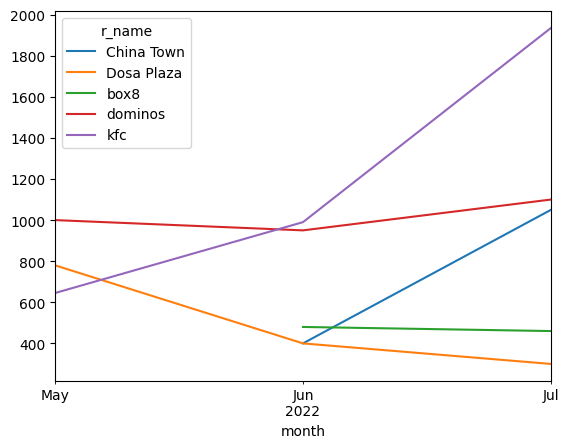

In [117]:
sales.plot(kind='line')


# Month over month revenue growth of swiggy

In [122]:
lov=pd.merge(food,details,how='inner',on='f_id')

In [123]:
lov

,f_id,f_name,type,id,order_id
0,1,Non-veg Pizza,Non-veg,1,1001
1,1,Non-veg Pizza,Non-veg,11,1006
2,1,Non-veg Pizza,Non-veg,23,1011
3,1,Non-veg Pizza,Non-veg,38,1021
4,1,Non-veg Pizza,Non-veg,40,1022
5,2,Veg Pizza,Veg,12,1006
6,3,Choco Lava cake,Veg,2,1001
7,3,Choco Lava cake,Veg,4,1002
8,3,Choco Lava cake,Veg,6,1003
9,3,Choco Lava cake,Veg,8,1004


In [131]:
lov.groupby('f_name')['f_id'].count().sort_values(ascending=False)

f_name
Choco Lava cake     13
Chicken Wings        8
Non-veg Pizza        5
Masala Dosa          4
Rice Meal            4
Schezwan Noodles     4
Veg Manchurian       4
Chicken Popcorn      3
Rava Idli            3
Roti meal            1
Veg Pizza            1
Name: f_id, dtype: int64